# 07 -- Model sprawnosci turbiny

Ten notebook przedstawia modele turbin wodnych dla MEW:

1. **Katalog turbin** -- Kaplan, Francis, smiglowa, przeplywowa
2. **Krzywe sprawnosci** -- eta_t = f(Q/Q_design) dla kazdego typu
3. **Wymiarowanie wirnika** -- srednica D1, obroty n z parametrow jednostkowych Q11, n11
4. **Predkosc szybkobieznosci** -- nsN i dobor typu turbiny
5. **Zakres stosowalnosci H-Q** -- ktore turbiny pasuja do naszego przypadku
6. **Praca wieloturbinowa** -- rozdzial przeplywu na N turbin

Modele zaimplementowane w module `src/turbine.py`.

---

## Modul `src/turbine.py`

**Prompt do LLM tworzacy ten modul:**
> *"Stworz modul src/turbine.py do modelowania turbin wodnych.
> Modul powinien zawierac: (1) dataclass TurbineType z parametrami turbiny
> (Q11, n11, krzywa sprawnosci, zakres pracy), (2) katalog TURBINE_CATALOG
> z typami Kaplan/Francis/smiglowa/przeplywowa + modele PL10/PL20 z arkusza Excel,
> (3) turbine_efficiency(Q_ratio, type) -- interpolacja krzywej sprawnosci,
> (4) runner_diameter, rotational_speed, synchronous_speed, specific_speed --
> wymiarowanie z praw podobienstwa, (5) filter_applicable_turbines(H, Q),
> (6) dispatch_flow -- rozdzial przeplywu na N identycznych turbin."*

**Funkcje w module:**
- `TurbineType` -- dataclass z parametrami turbiny
- `TURBINE_CATALOG` -- slownik z 6 typami turbin
- `turbine_efficiency(Q_ratio, type)` -- sprawnosc z interpolacji krzywej
- `runner_diameter(Q_design, H, type)` -- srednica wirnika
- `rotational_speed(H, D1, type)` -- predkosc obrotowa
- `synchronous_speed(n_raw)` -- najblizsze obroty synchroniczne
- `specific_speed(n, P, H)` -- predkosc szybkobieznosci nsN
- `filter_applicable_turbines(H, Q)` -- filtruj pasujace typy
- `dispatch_flow(Q_avail, Q_design, n_turb, type)` -- rozdzial przeplywu

## Konfiguracja

**Prompt do LLM:**
> *"Napisz kod konfiguracji notebooka: zaladuj modul src/turbine (TurbineType, TURBINE_CATALOG,
> turbine_efficiency, runner_diameter, rotational_speed, synchronous_speed, specific_speed,
> filter_applicable_turbines, dispatch_flow). Wyswietl liczbe typow w katalogu."*

**Uzyte moduly/funkcje:** `src.turbine`: TurbineType, TURBINE_CATALOG, turbine_efficiency, runner_diameter, rotational_speed, synchronous_speed, specific_speed, filter_applicable_turbines, dispatch_flow

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.turbine import (
    TurbineType,
    TURBINE_CATALOG,
    turbine_efficiency,
    runner_diameter,
    rotational_speed,
    synchronous_speed,
    specific_speed,
    filter_applicable_turbines,
    dispatch_flow,
)

print(f'Zaladowano katalog z {len(TURBINE_CATALOG)} typami turbin.')

Zaladowano katalog z 6 typami turbin.


---
## Krok 1: Katalog turbin

| Typ | Regulacja | Zakres H [m] | eta_peak | Zalety |
|-----|-----------|-------------|----------|--------|
| **Kaplan** | podwojna (lopaty + kierownica) | 1--20 | 0.92 | Plaska krzywa sprawnosci, szeroki zakres pracy |
| **Francis** | kierownica | 10--350 | 0.93 | Najwyzsza sprawnosc szczytkowa, duze spady |
| **Smiglowa** | brak (stale lopaty) | 1--15 | 0.90 | Tansza od Kaplana, ale waski zakres |
| **Przeplywowa** | -- | 1--200 | 0.84 | Prosta konstrukcja, dobra przy malych Q |

**Prompt do LLM:**
> *"Wyswietl katalog turbin jako tabelke z parametrami: nazwa, Q11, n11,
> eta_peak, zakres H, min/max Q_ratio."*

**Uzyte funkcje:** `src.turbine.TURBINE_CATALOG`

In [2]:
rows = []
for name, t in TURBINE_CATALOG.items():
    rows.append({
        'Typ': t.name_pl,
        'Q11': t.Q11,
        'n11': t.n11,
        'eta_peak': t.eta_peak,
        'H_min [m]': t.H_range[0],
        'H_max [m]': t.H_range[1],
        'Q_ratio_min': t.Q_ratio_min,
        'Q_ratio_max': t.Q_ratio_max,
    })
pd.DataFrame(rows)

,Typ,Q11,n11,eta_peak,H_min [m],H_max [m],Q_ratio_min,Q_ratio_max
0,Kaplan (podwojnie regulowana),1.20,158.0,0.920,1.0,20.0,0.15,1.1
1,Francis,0.80,120.0,0.930,10.0,350.0,0.40,1.0
2,Smiglowa (stale lopaty),1.05,133.0,0.900,1.0,15.0,0.65,1.0
3,Przeplywowa (Banki-Michell),0.45,40.0,0.840,1.0,200.0,0.10,1.0
4,PL 10 (Kaplan),1.20,158.0,0.876,1.0,20.0,0.15,1.0
5,PL 20 (Kaplan),1.05,133.0,0.900,1.0,20.0,0.20,1.0


---
## Krok 2: Krzywe sprawnosci

Sprawnosc turbiny zalezy od **obciazenia wzglednego** $Q/Q_{design}$:

$$\eta_t = f\left(\frac{Q}{Q_{design}}\right)$$

Kazdy typ turbiny ma inna charakterystyke:
- **Kaplan**: plaska krzywa -- wysoka sprawnosc w szerokim zakresie (15--110% Q_design)
- **Francis**: ostre maksimum -- najwyzsza szczytowa, ale szybko spada ponizej 60%
- **Smiglowa**: bardzo strome opadanie ponizej 80% -- waski zakres pracy
- **Przeplywowa**: umiarkowana, stabilna od 10% do 100%

**Ponizej Q_min turbina nie moze pracowac** (kawitacja, niestabilnosc).

**Prompt do LLM:**
> *"Narysuj krzywe sprawnosci eta(Q/Q_design) dla 4 glownych typow turbin
> na jednym wykresie. Uzyj plotly, zakres Q_ratio 0-1.2."*

**Uzyte funkcje:** `src.turbine.turbine_efficiency()`

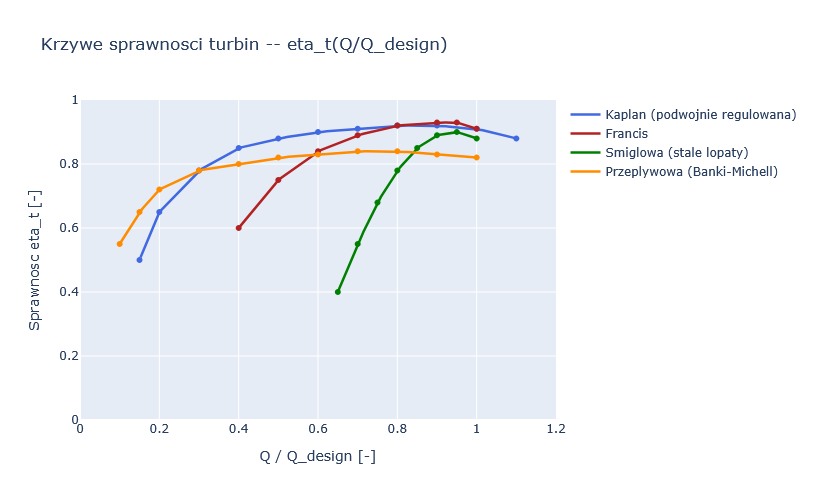

In [3]:
Q_ratio = np.linspace(0.0, 1.2, 300)

colors = {
    'kaplan': 'royalblue', 'francis': 'firebrick',
    'propeller': 'green', 'crossflow': 'darkorange',
}
main_types = ['kaplan', 'francis', 'propeller', 'crossflow']

fig = go.Figure()
for name in main_types:
    t = TURBINE_CATALOG[name]
    eta = turbine_efficiency(Q_ratio, t)
    # Show only where eta > 0
    eta_plot = np.where(eta > 0, eta, np.nan)
    fig.add_trace(go.Scatter(
        x=Q_ratio, y=eta_plot,
        mode='lines', name=t.name_pl,
        line=dict(color=colors[name], width=2.5),
    ))
    # Mark data points
    fig.add_trace(go.Scatter(
        x=list(t.eta_curve_q), y=list(t.eta_curve_eta),
        mode='markers', showlegend=False,
        marker=dict(color=colors[name], size=6),
    ))

fig.update_layout(
    title='Krzywe sprawnosci turbin -- eta_t(Q/Q_design)',
    xaxis_title='Q / Q_design [-]',
    yaxis_title='Sprawnosc eta_t [-]',
    yaxis_range=[0, 1.0],
    height=500, hovermode='x unified',
)
fig.show()

### Modele PL10 i PL20 (z arkusza Excel)

Modele PL10 i PL20 to konkretne turbiny smiglowe/Kaplana z katalogu producenta
(parametry z arkusza WPE_2.xlsm):

**Prompt do LLM:**
> *"Porownaj krzywe sprawnosci modeli PL10 i PL20 z ogolna krzywa Kaplana
> na jednym wykresie. Wyswietl jako linie ciagle, Kaplan ogolny przerywany."*

**Uzyte funkcje:** `src.turbine.TURBINE_CATALOG`, `src.turbine.turbine_efficiency()`

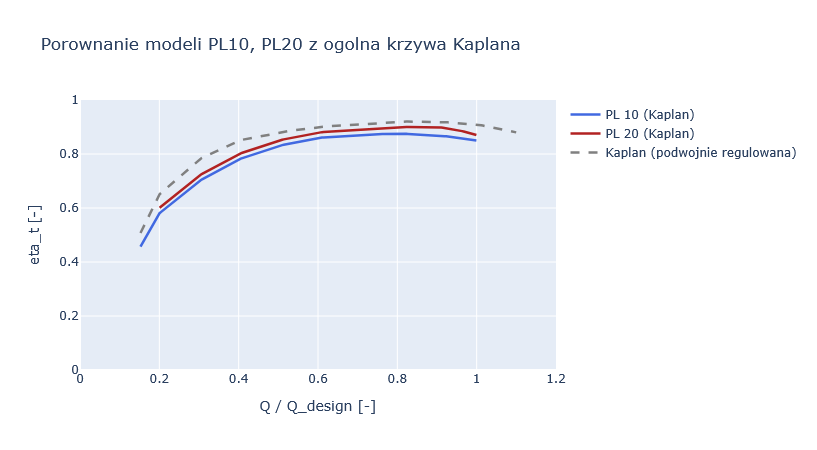

In [4]:
fig = go.Figure()
for name, color in [('pl10', 'royalblue'), ('pl20', 'firebrick'), ('kaplan', 'gray')]:
    t = TURBINE_CATALOG[name]
    eta = turbine_efficiency(Q_ratio, t)
    eta_plot = np.where(eta > 0, eta, np.nan)
    fig.add_trace(go.Scatter(
        x=Q_ratio, y=eta_plot,
        mode='lines', name=t.name_pl,
        line=dict(color=color, width=2.5, dash='dash' if name=='kaplan' else 'solid'),
    ))

fig.update_layout(
    title='Porownanie modeli PL10, PL20 z ogolna krzywa Kaplana',
    xaxis_title='Q / Q_design [-]', yaxis_title='eta_t [-]',
    yaxis_range=[0, 1.0], height=450, hovermode='x unified',
)
fig.show()

---
## Krok 3: Wymiarowanie wirnika

Z **praw podobienstwa** turbin wodnych:

$$Q = Q_{11} \cdot D_1^2 \cdot \sqrt{H}$$

$$n = n_{11} \cdot \frac{\sqrt{H}}{D_1}$$

Stad srednica wirnika:

$$D_1 = \sqrt{\frac{Q_{design}}{Q_{11} \cdot \sqrt{H}}}$$

gdzie:
- $Q_{11}$ -- przeplyw jednostkowy [m$^3$/s] (parametr turbiny)
- $n_{11}$ -- predkosc jednostkowa [obr/min] (parametr turbiny)
- $D_1$ -- srednica wirnika [m]
- $H$ -- spad [m]

Predkosc obrotowa musi byc **synchroniczna** z siecia ($n_{sync} = 60f/p$).

**Prompt do LLM:**
> *"Napisz kod ktory dla H=6m i Q_design=11.7 m3/s (na turbine) obliczy
> srednice wirnika D1, obroty n, obroty synchroniczne i predkosc szybkobieznosci
> dla kazdego typu turbiny z katalogu. Wyswietl tabelke."*

**Uzyte funkcje:** `runner_diameter()`, `rotational_speed()`, `synchronous_speed()`, `specific_speed()`

In [5]:
H = 6.0       # m
Q_des = 11.7  # m3/s (na turbine)
rho = 998
g = 9.81

rows = []
for name, t in TURBINE_CATALOG.items():
    D1 = runner_diameter(Q_des, H, t)
    n_raw = rotational_speed(H, D1, t)
    n_sync, poles = synchronous_speed(n_raw)
    P_kW = rho * g * Q_des * H * t.eta_peak / 1000
    nsN = specific_speed(n_sync, P_kW, H)
    rows.append({
        'Typ': t.name_pl,
        'D1 [m]': round(D1, 3),
        'n [obr/min]': round(n_raw, 1),
        'n_sync': round(n_sync, 0),
        'Biegunow': poles,
        'P [kW]': round(P_kW, 0),
        'nsN': round(nsN, 0),
    })

print(f'Wymiarowanie wirnika: H={H}m, Q_design={Q_des} m3/s')
pd.DataFrame(rows)

Wymiarowanie wirnika: H=6.0m, Q_design=11.7 m3/s


,Typ,D1 [m],n [obr/min],n_sync,Biegunow,P [kW],nsN
0,Kaplan (podwojnie regulowana),1.995,194.0,200.0,30,632.0,536.0
1,Francis,2.443,120.3,200.0,30,639.0,538.0
2,Smiglowa (stale lopaty),2.133,152.7,200.0,30,619.0,530.0
3,Przeplywowa (Banki-Michell),3.258,30.1,200.0,30,577.0,512.0
4,PL 10 (Kaplan),1.995,194.0,200.0,30,602.0,523.0
5,PL 20 (Kaplan),2.133,152.7,200.0,30,619.0,530.0


---
## Krok 4: Predkosc szybkobieznosci i dobor typu

**Predkosc szybkobieznosci** $n_{sN}$ to parametr bezwymiarowy okreslajacy
typ turbiny:

$$n_{sN} = n \cdot \frac{\sqrt{P}}{H^{5/4}}$$

| nsN | Typ turbiny |
|-----|-------------|
| < 100 | Pelton |
| 100--400 | Francis (wolnobiezna) |
| 400--700 | Francis (szybkobiezna) |
| 600--900 | Kaplan / smiglowa |
| > 800 | Turbina osiowa (bulb) |

nsN dla H=6.0 m, Q_design=11.7 m3/s:


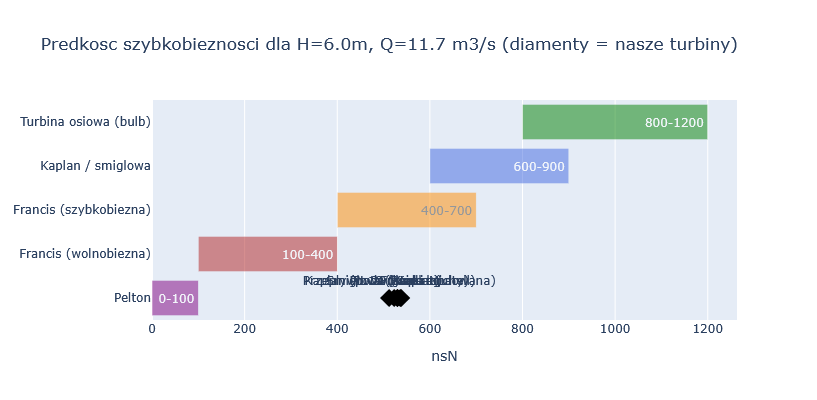

,Typ,n_sync,P [kW],nsN
0,Kaplan (podwojnie regulowana),200.0,632,536
1,Francis,200.0,639,538
2,Smiglowa (stale lopaty),200.0,619,530
3,Przeplywowa (Banki-Michell),200.0,577,512
4,PL 10 (Kaplan),200.0,602,523
5,PL 20 (Kaplan),200.0,619,530


In [6]:
# Predkosc szybkobieznosci dla naszych warunkow (H=6m, Q_design=11.7 m3/s na turbine)
H = 6.0
Q_des = 11.7

print(f'nsN dla H={H} m, Q_design={Q_des} m3/s:')
rows = []
for name, t in TURBINE_CATALOG.items():
    D1 = runner_diameter(Q_des, H, t)
    n_raw = rotational_speed(H, D1, t)
    n_sync, _ = synchronous_speed(n_raw)
    P_kW = 998 * 9.81 * Q_des * H * t.eta_peak / 1000
    nsN = specific_speed(n_sync, P_kW, H)
    rows.append({'Typ': t.name_pl, 'n_sync': n_sync, 'P [kW]': round(P_kW), 'nsN': round(nsN)})
df_ns = pd.DataFrame(rows)

# Wykres pasm nsN z punktami dla naszych turbin
ranges = [
    ('Pelton',                    0,  100, 'purple'),
    ('Francis (wolnobiezna)',   100,  400, 'firebrick'),
    ('Francis (szybkobiezna)',  400,  700, 'darkorange'),
    ('Kaplan / smiglowa',       600,  900, 'royalblue'),
    ('Turbina osiowa (bulb)',   800, 1200, 'green'),
]
fig = go.Figure()
for label, lo, hi, color in ranges:
    fig.add_trace(go.Bar(
        y=[label], x=[hi - lo], base=[lo],
        orientation='h', marker_color=color, opacity=0.5,
        text=f'{lo}-{hi}', textposition='inside', showlegend=False,
    ))
# nasze turbiny
for _, r in df_ns.iterrows():
    fig.add_trace(go.Scatter(
        x=[r['nsN']], y=['Pelton'], mode='markers+text',
        marker=dict(symbol='diamond', size=14, color='black'),
        text=[r['Typ']], textposition='top center', showlegend=False,
    ))

fig.update_layout(
    title=f'Predkosc szybkobieznosci dla H={H}m, Q={Q_des} m3/s (diamenty = nasze turbiny)',
    xaxis_title='nsN', height=400, barmode='overlay',
)
fig.show()
df_ns

**Prompt do LLM:**
> *"Dla naszego przypadku (H=6m, Q_design=11.7 m3/s) oblicz nsN dla kazdego
> typu turbiny i zaznacz wynik na wykresie przedzialow nsN. Pokaz, ktore
> typy pasuja zakresowo do obliczonej wartosci."*

**Uzyte funkcje:** `src.turbine.specific_speed()`

---
## Krok 5: Zakres stosowalnosci H-Q

Kazdy typ turbiny ma zakres spadow H i przeplywow Q w ktorym moze pracowac.
Ten wykres pomaga w wstepnym doborze typu.

**Prompt do LLM:**
> *"Narysuj wykres stosowalnosci H-Q: dla kazdego typu turbiny zaznacz obszar
> (H_min-H_max) jako poziome pasy. Zaznacz nasz punkt projektowy (H=6m)."*

**Uzyte funkcje:** `src.turbine.filter_applicable_turbines()`

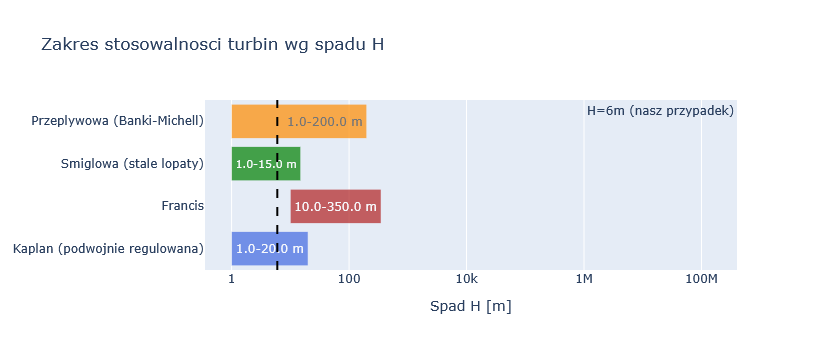

Turbiny pasujace dla H=6m: ['Kaplan (podwojnie regulowana)', 'Smiglowa (stale lopaty)', 'Przeplywowa (Banki-Michell)', 'PL 10 (Kaplan)', 'PL 20 (Kaplan)']


In [7]:
# Wykres stosowalnosci H-Q
main_types = ['kaplan', 'francis', 'propeller', 'crossflow']
colors_map = {'kaplan': 'royalblue', 'francis': 'firebrick',
              'propeller': 'green', 'crossflow': 'darkorange'}

fig = go.Figure()
for i, name in enumerate(main_types):
    t = TURBINE_CATALOG[name]
    H_min, H_max = t.H_range
    fig.add_trace(go.Bar(
        y=[t.name_pl], x=[H_max - H_min], base=[H_min],
        orientation='h', name=t.name_pl,
        marker_color=colors_map[name], opacity=0.7,
        text=f'{H_min}-{H_max} m', textposition='inside',
    ))

fig.add_vline(x=6.0, line_dash='dash', line_color='black',
    annotation_text='H=6m (nasz przypadek)')

fig.update_layout(
    title='Zakres stosowalnosci turbin wg spadu H',
    xaxis_title='Spad H [m]', xaxis_type='log',
    height=350, showlegend=False, barmode='overlay',
)
fig.show()

# Filtruj pasujace
valid = filter_applicable_turbines(H=6.0, Q_design=50)
print(f'Turbiny pasujace dla H=6m: {[TURBINE_CATALOG[k].name_pl for k in valid]}')

---
## Krok 6: Praca wieloturbinowa -- rozdzial przeplywu

Przy wielu identycznych turbinach dostepny przeplyw rozdzielamy tak,
aby kazda dzialajaca jednostka byla **jak najblizej swojego punktu projektowego** (najlepsza sprawnosc):

1. Liczba aktywnych turbin: $n_{active} = \min\big(n_{turbines},\; \max(1,\; \lceil Q / Q_{design} \rceil)\big)$
2. Przeplyw na turbine: $Q_{per} = \min(Q / n_{active},\; Q_{design})$
3. Jesli $Q_{per} < Q_{min}$ przy $n_{active}=1$ — elektrownia stoi (jeden niedociazony agregat tez nie zaplaci za pracujace pompy olejowe).

**Zaleta wielu turbin:** wieksza moc zainstalowana (mozemy "lapac" wieksze przeplywy)
i mniej wody traconej na przelewie przy szczytach. Przy bardzo niskich przeplywach
dzialanie wszystkich konfiguracji jest podobne — zostaje jedna turbina lub plant stoi.

**Prompt do LLM:**
> *"Porownaj prace 1 turbiny vs 2 turbin vs 4 turbin dla tego samego calkowitego
> Q_design. Pokaz jak sprawnosc zmienia sie w funkcji Q/Q_total_design.
> Uzyj turbiny Kaplana."*

**Uzyte funkcje:** `src.turbine.dispatch_flow()`, `src.turbine.turbine_efficiency()`

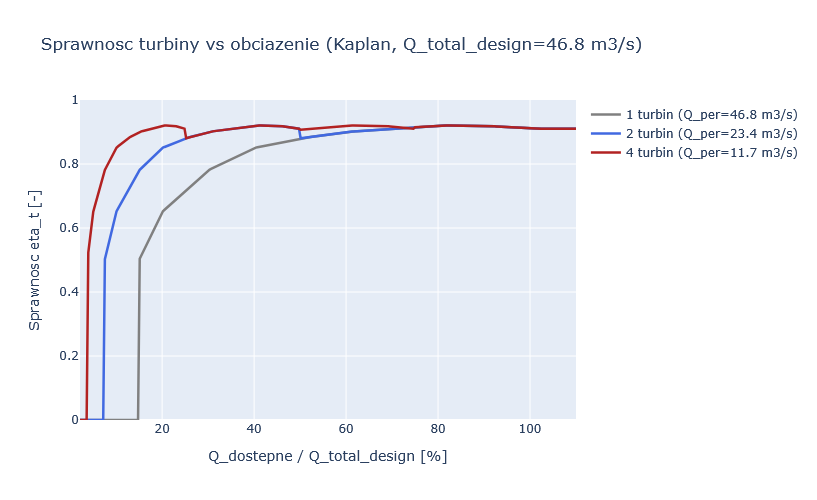

Strategia rozdzialu: minimalna liczba turbin, kazda <= Q_design.
Konfiguracja z mniejszymi turbinami (wiecej sztuk) lepiej skaluje sie
w gore (mozna uzyc wiekszej czesci przeplywu), w dol — sytuacja podobna
(zostaje 1 turbina, niezaleznie ile jest zainstalowanych).


In [8]:
Q_total_design = 46.8  # m3/s (calkowity przeplyw projektowy)
kaplan = TURBINE_CATALOG['kaplan']

Q_avail = np.linspace(1, Q_total_design * 1.1, 300)

fig = go.Figure()
for n_turb, color in [(1, 'gray'), (2, 'royalblue'), (4, 'firebrick')]:
    Q_per_turb = Q_total_design / n_turb  # Q_design per turbine
    Q_each, n_act = dispatch_flow(Q_avail, Q_per_turb, n_turb, kaplan)
    Q_ratio = np.where(Q_per_turb > 0, Q_each / Q_per_turb, 0.0)
    eta = turbine_efficiency(Q_ratio, kaplan)
    fig.add_trace(go.Scatter(
        x=Q_avail / Q_total_design * 100, y=eta,
        mode='lines', name=f'{n_turb} turbin (Q_per={Q_per_turb:.1f} m3/s)',
        line=dict(color=color, width=2.5),
    ))

fig.update_layout(
    title=f'Sprawnosc turbiny vs obciazenie (Kaplan, Q_total_design={Q_total_design} m3/s)',
    xaxis_title='Q_dostepne / Q_total_design [%]',
    yaxis_title='Sprawnosc eta_t [-]',
    yaxis_range=[0, 1.0],
    height=500, hovermode='x unified',
)
fig.show()

print('Strategia rozdzialu: minimalna liczba turbin, kazda <= Q_design.')
print('Konfiguracja z mniejszymi turbinami (wiecej sztuk) lepiej skaluje sie')
print('w gore (mozna uzyc wiekszej czesci przeplywu), w dol — sytuacja podobna')
print('(zostaje 1 turbina, niezaleznie ile jest zainstalowanych).')

---
## Podsumowanie

W tym notebooku przedstawiono:

| Model | Opis | Funkcja |
|-------|------|---------|
| Katalog turbin | 6 typow z parametrami | `TURBINE_CATALOG` |
| Sprawnosc | eta_t(Q/Q_design) z interpolacji | `turbine_efficiency()` |
| Wymiarowanie | D1, n z Q11/n11 | `runner_diameter()`, `rotational_speed()` |
| Predkosc szybkobieznosci | nsN | `specific_speed()` |
| Stosowalnosc | filtrowanie po H | `filter_applicable_turbines()` |
| Wieloturbinowa praca | rozdzial Q na N turbin | `dispatch_flow()` |

**Kluczowe wnioski:**
- Kaplan najlepsza dla niskich spadow (H=6m) -- szeroki zakres pracy
- Wiecej turbin poprawia sprawnosc przy niskich przeplywach
- Francis nie pasuje do H=6m (wymaga H>=10m)

**Dalej:** notebook 08 -- model sprawnosci generatora